In [23]:
# =========================
# Imports & Basic Settings
# =========================

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN

# Optional: warnings & reproducibility
import warnings
warnings.filterwarnings("ignore")

# Matplotlib defaults (neutral; adjust later if needed)
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.6

In [24]:
# ============================================
# Synthetic datasets for clustering (cleaned)
# ============================================

from collections import OrderedDict
# ---- Parameters (adjust here) ----
N_SAMPLES    = 500
SEED         = 30          # for circles/moons/blobs + "no structure"
RANDOM_STATE = 170         # for anisotropic/varied variants
CENTERS      = 3           # default centers for blobs-like sets

def generate_synthetic_datasets(
    n_samples: int = N_SAMPLES,
    seed: int = SEED,
    alt_state: int = RANDOM_STATE,
    centers: int = CENTERS,
):
    """
    Return an OrderedDict of named synthetic datasets as (X, y) tuples:
      - Noisy Circles
      - Noisy Moons
      - Blobs
      - No Structure (uniform noise, single label 0)
      - Anisotropic (linear transform of blobs)
      - Varied Std (different cluster stds)

    Parameters
    ----------
    n_samples : int
        Total points per dataset.
    seed : int
        Random seed for base generators.
    alt_state : int
        Alternate seed for derived variants (anisotropic/varied).
    centers : int
        Number of centers for blobs-like datasets.
    """
    rng = np.random.RandomState(seed)

    # Base sets
    noisy_circles = make_circles(
        n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
    )
    noisy_moons = make_moons(
        n_samples=n_samples, noise=0.05, random_state=seed
    )
    blobs = make_blobs(
        n_samples=n_samples, centers=centers, random_state=seed
    )

    # No structure: 2D uniform noise with a single dummy label (0)
    no_structure = (rng.rand(n_samples, 2), np.zeros(n_samples, dtype=np.int8))

    # Anisotropic variant: linear transform applied to a fresh blobs sample
    X_base, y_base = make_blobs(
        n_samples=n_samples, centers=centers, random_state=alt_state
    )
    transform = np.array([[0.6, -0.6],
                          [-0.4,  0.8]], dtype=float)
    X_aniso = X_base @ transform
    aniso = (X_aniso, y_base)

    # Varied std: different dispersion per cluster
    varied = make_blobs(
        n_samples=n_samples,
        centers=centers,
        cluster_std=[1.1, 2.5, 0.7],
        random_state=alt_state,
    )

    # Keep a predictable, readable order
    datasets = OrderedDict(
        [
            ("Blobs", blobs),
            ("Noisy circles", noisy_circles),
            ("Noisy moons", noisy_moons),
            ("No structure", no_structure),
            ("Anisotropic", aniso),
            ("Varied std", varied),
        ]
    )
    return datasets

# Build the datasets dictionary
datasets = generate_synthetic_datasets()

# (Optional) quick sanity check
for name, (X, y) in datasets.items():
    assert X.shape[0] == y.shape[0], f"Length mismatch in {name}"


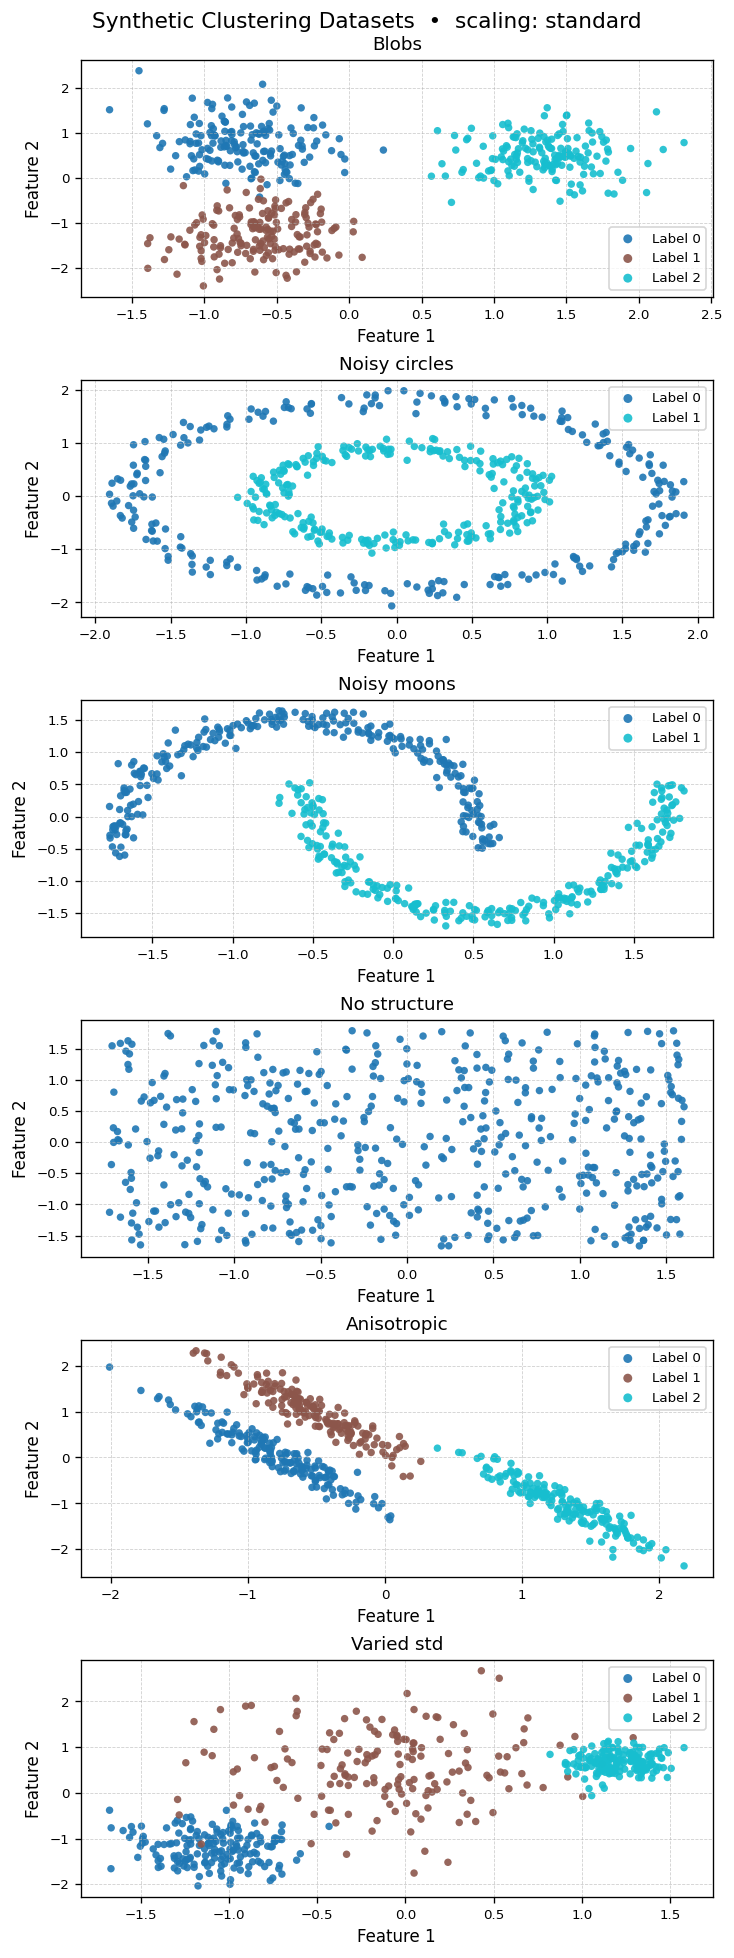

In [16]:
# ============================================
# Plot helper for synthetic clustering datasets
# ============================================

from typing import Iterable, Mapping, Tuple, Optional, Union

ArrayLike = np.ndarray
Dataset = Tuple[ArrayLike, ArrayLike]  # (X, y)
DSInput = Union[Mapping[str, Dataset], Iterable[Tuple[str, Dataset]]]

def _get_scaler(name: Optional[str]):
    if name is None or str(name).lower() in {"none", "off", "no"}:
        return None
    if str(name).lower() in {"standard", "z", "zscore"}:
        return StandardScaler()
    if str(name).lower() in {"minmax", "min-max", "01"}:
        return MinMaxScaler()
    raise ValueError("scale must be one of: None/'none', 'standard', 'minmax'")

def plot_datasets(
    datasets: DSInput,
    *,
    scale: Optional[str] = "standard",
    figsize: Tuple[int, int] = (6, 14),
    point_size: int = 20,
    alpha: float = 0.9,
    title: str = "Synthetic Clustering Datasets",
    equal_aspect: bool = False,
):
    """
    Plot multiple (X, y) datasets in a neat vertical stack.

    Parameters
    ----------
    datasets : mapping or iterable
        Either an OrderedDict-like {name: (X, y)} or an iterable of (name, (X, y)).
    scale : {'standard', 'minmax', None}
        Per-plot feature scaling. 'standard' applies StandardScaler, 'minmax' applies MinMaxScaler,
        None leaves raw features.
    figsize : tuple
        Figure size in inches.
    point_size : int
        Scatter point area (matplotlib 's').
    alpha : float
        Point transparency.
    title : str
        Figure-level title.
    equal_aspect : bool
        If True, use equal aspect ratio per axes.
    """
    # normalize input to list of (name, (X, y))
    if isinstance(datasets, Mapping):
        items = list(datasets.items())
    else:
        items = list(datasets)

    scaler = _get_scaler(scale)

    n = len(items)
    fig, axes = plt.subplots(n, 1, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (name, (X, y)) in zip(axes, items):
        Xp = X.copy()
        if scaler is not None:
            Xp = scaler.fit_transform(Xp)

        # robust label handling
        y_arr = np.asarray(y)
        unique = np.unique(y_arr)

        # choose colormap with enough distinct colors
        base_cmap = plt.cm.get_cmap("tab20" if len(unique) > 10 else "tab10")
        colors = base_cmap(np.linspace(0, 1, max(len(unique), 2)))

        # plot by label for clean legend
        for idx, (lbl, clr) in enumerate(zip(unique, colors)):
            mask = (y_arr == lbl)
            ax.scatter(
                Xp[mask, 0], Xp[mask, 1],
                s=point_size, c=[clr], alpha=alpha,
                label=f"Label {lbl}",
                edgecolors="none",
            )

        ax.set_title(name, fontsize=11, pad=6)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
        ax.tick_params(axis="both", labelsize=8)
        if equal_aspect:
            ax.set_aspect("equal", adjustable="datalim")
        # show legend only if there is more than one distinct label
        if len(unique) > 1:
            ax.legend(loc="best", fontsize=8, frameon=True, markerscale=1.2)

    fig.suptitle(
        f"{title}  •  scaling: {('none' if scaler is None else scale)}",
        fontsize=13, y=1.01
    )
    plt.show()

plot_datasets(datasets, scale="standard", figsize=(6, 16), equal_aspect=False)


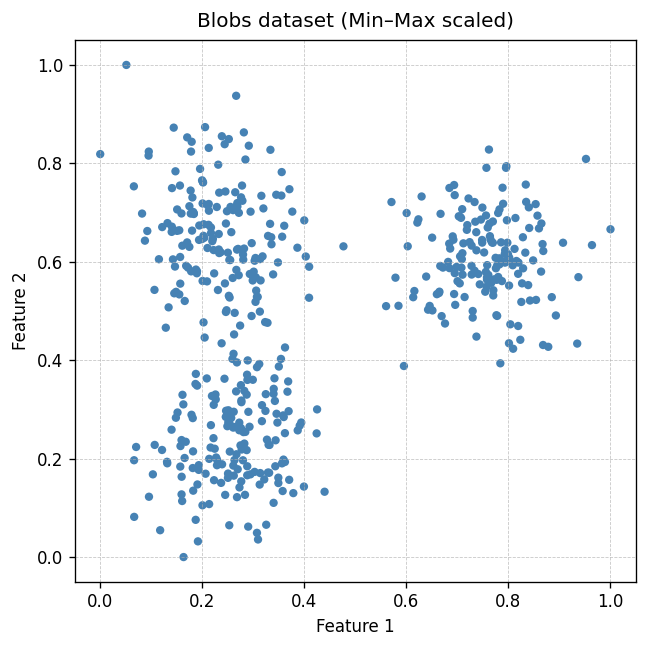

In [17]:
# ============================
# Select and preview one dataset
# ============================
# pick a dataset (here: 'Blobs')
X, y = datasets["Blobs"]  # each dataset is (X, y)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25,
    alpha=1,
    color="steelblue",
    edgecolors="none"
)
plt.title("Blobs dataset (Min–Max scaled)", fontsize=12, pad=8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


## Clustering
### **Within-Cluster Sum of Squares (WCSS)** metric

In [18]:
# ======================================
# Compute WCSS (Elbow Method) for K-Means
# ======================================

WCSS = []
MODELS = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=20,          # more restarts for stable results
        random_state=SEED,  # use global seed for reproducibility
    )
    km.fit(X_scaled)
    MODELS.append(km)
    WCSS.append(km.inertia_)

# Optional: sanity check
print(f"Computed WCSS for k = {list(K_RANGE)}")


Computed WCSS for k = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


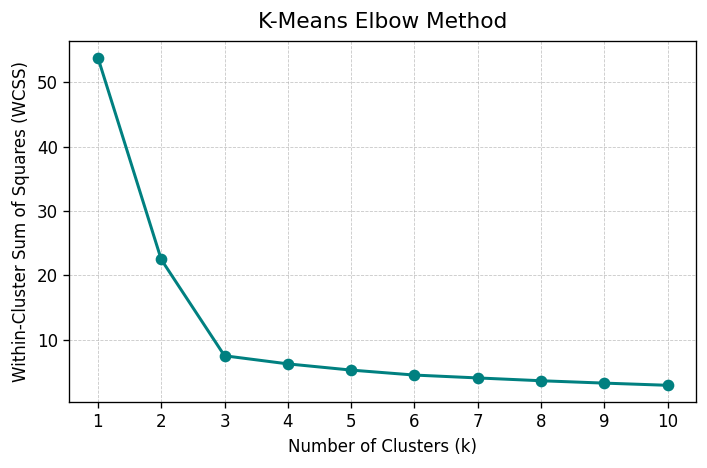

In [19]:
# ======================================
# Plot Elbow Curve (WCSS vs Number of Clusters)
# ======================================

plt.figure(figsize=(6, 4))
plt.plot(K_RANGE, WCSS, marker='o', linewidth=1.8, markersize=6, color='teal')
plt.title("K-Means Elbow Method", fontsize=13, pad=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(K_RANGE)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


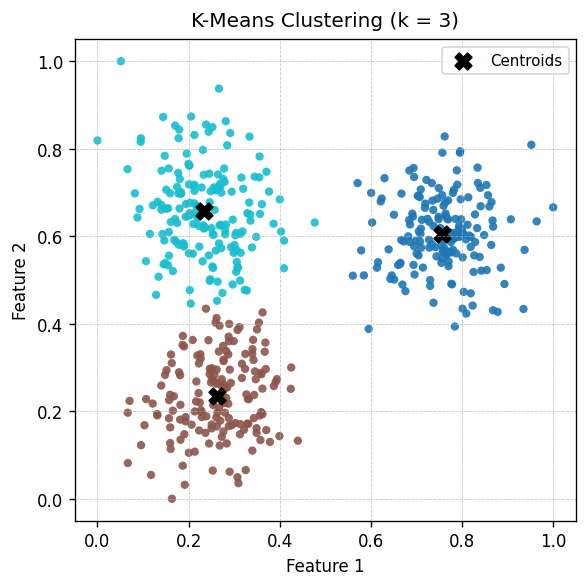

In [20]:
# ======================================
# Visualize K-Means Clustering (k = 3)
# ======================================

# Choose the model corresponding to k = 3
K_SELECTED = 3
kmeans = MODELS[K_SELECTED - 1]   # because list index starts at 0
yp = kmeans.fit_predict(X_scaled)

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=yp,
    cmap="tab10",   # better perceptual colormap than jet
    s=25,
    alpha=0.9,
    edgecolors="none"
)

# Add cluster centers
centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=100,
    c="black",
    marker="X",
    label="Centroids"
)

ax.set_title(f"K-Means Clustering (k = {K_SELECTED})", fontsize=12, pad=8)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(frameon=True, fontsize=9, loc="best")
plt.tight_layout()
plt.show()


## DBSCAN
### **Density-Based Spatial Clustering Applications With Noise**

DBSCAN found 4 clusters and 76 noise points


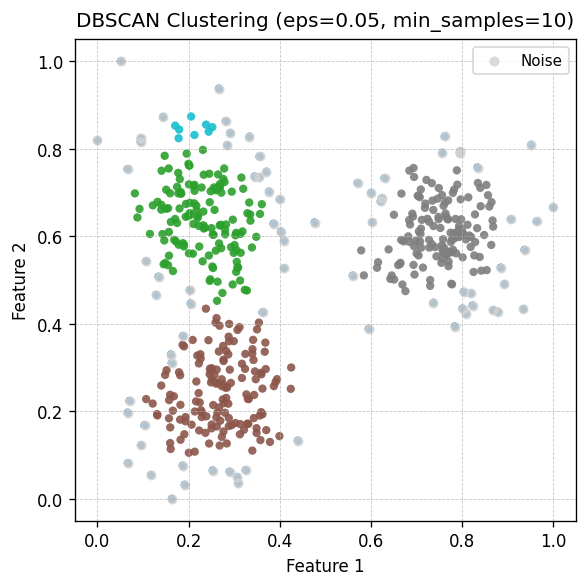

In [21]:
# =====================================
# DBSCAN Clustering & Visualization
# =====================================

from sklearn.cluster import DBSCAN

# Instantiate DBSCAN with parameters you can tune later
dbscan = DBSCAN(eps=0.05, min_samples=10)
yp_db = dbscan.fit_predict(X_scaled)

# Identify number of clusters and noise
labels_unique = np.unique(yp_db)
n_clusters = len(labels_unique[labels_unique != -1])
n_noise = np.sum(yp_db == -1)

print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points")

# Plot results
fig, ax = plt.subplots(figsize=(5, 5))
scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=yp_db,
    cmap="tab10",       # consistent colormap with K-Means
    s=25,
    alpha=0.9,
    edgecolors="none"
)

# Highlight noise points (label = -1) in gray
if np.any(yp_db == -1):
    ax.scatter(
        X_scaled[yp_db == -1, 0],
        X_scaled[yp_db == -1, 1],
        s=25,
        c="lightgray",
        alpha=0.8,
        label="Noise"
    )

ax.set_title(f"DBSCAN Clustering (eps={dbscan.eps}, min_samples={dbscan.min_samples})",
             fontsize=12, pad=8)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(frameon=True, fontsize=9, loc="best")
plt.tight_layout()
plt.show()


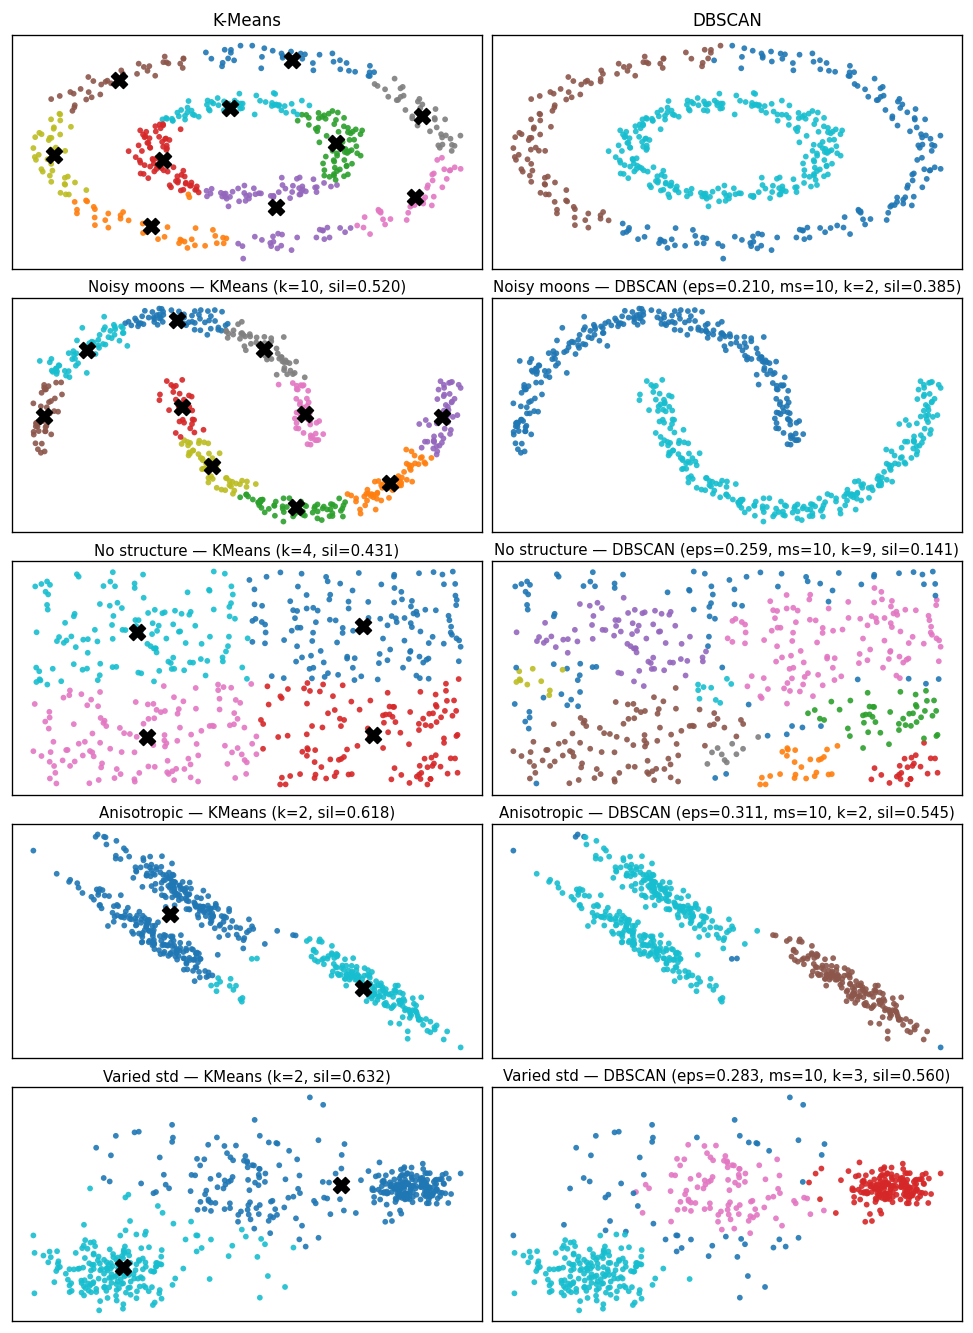

,kmeans_k,kmeans_silhouette,dbscan_eps,dbscan_min_samples,dbscan_clusters,dbscan_noise_points,dbscan_silhouette
Noisy circles,10.0,0.431160,0.279096,10.0,3.0,0.0,0.181213
Noisy moons,10.0,0.519752,0.209955,10.0,2.0,0.0,0.385319
No structure,4.0,0.431034,0.259085,10.0,9.0,90.0,0.141324
Anisotropic,2.0,0.617844,0.310724,10.0,2.0,7.0,0.545384
Varied std,2.0,0.632218,0.283361,10.0,3.0,56.0,0.560335


In [25]:
# ===================================================
# Compact matrix plots: K-Means vs DBSCAN per dataset
# (excludes 'Blobs'; small, optimized & reproducible)
# ===================================================

from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

SEED = 30

# --- helpers (lean) ---

def scale(X):
    return StandardScaler().fit_transform(X)

def best_k_silhouette(X, k_min=2, k_max=10, n_init=50, random_state=SEED):
    best = (None, -1.0, None)  # (k, score, model)
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state).fit(X)
        try:
            score = silhouette_score(X, km.labels_)
        except Exception:
            score = np.nan
        if np.isfinite(score) and score > best[1]:
            best = (k, score, km)
    # fallback if silhouette failed
    return best if best[0] is not None else (3, np.nan, KMeans(n_clusters=3, n_init=50, random_state=random_state).fit(X))

def eps_heuristic(X, min_samples=10, pct=90, sweep_width=0.25, steps=5):
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
    dists, _ = nbrs.kneighbors(X)
    kdist = np.sort(dists[:, -1])
    guess = float(np.percentile(kdist, pct))
    grid = np.linspace((1 - sweep_width) * guess, (1 + sweep_width) * guess, steps)
    best = (None, -2.0, None)  # (eps, silhouette, labels)
    for eps in grid:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            try:
                score = silhouette_score(X, labels)
            except Exception:
                score = np.nan
            if np.isfinite(score) and score > best[1]:
                best = (eps, score, labels)
    # fallback: use guess if sweep fails
    if best[0] is None:
        labels = DBSCAN(eps=guess, min_samples=min_samples).fit_predict(X)
        best = (guess, np.nan, labels)
    return best

def small_scatter(ax, X, labels, title, show_centroids=None):
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=12, alpha=0.9, edgecolors="none")
    if show_centroids is not None:
        ax.scatter(show_centroids[:, 0], show_centroids[:, 1], c="black", s=90, marker="X")
    ax.set_title(title, fontsize=9, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

# --- filter datasets (drop 'Blobs') ---
filtered = [(name, ds) for name, ds in datasets.items() if name.lower() != "blobs"]
n_rows = len(filtered)
n_cols = 2  # K-Means | DBSCAN

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2.2 * n_rows), constrained_layout=True)
if n_rows == 1:
    axes = np.array([axes])  # ensure 2D indexing

summary = {}

for r, (name, (X_raw, y_true)) in enumerate(filtered):
    X = scale(X_raw)

    # --- K-Means ---
    k_opt, sil_k, km_model = best_k_silhouette(X, k_min=2, k_max=10, n_init=50, random_state=SEED)
    km_labels = km_model.labels_
    small_scatter(
        axes[r, 0], X, km_labels,
        title=f"{name} — KMeans (k={k_opt}, sil={sil_k:.3f})" if np.isfinite(sil_k) else f"{name} — KMeans (k={k_opt})",
        show_centroids=km_model.cluster_centers_
    )

    # --- DBSCAN ---
    min_samples = 10 if X.shape[1] <= 2 else 2 * X.shape[1]
    eps_opt, sil_db, db_labels = eps_heuristic(X, min_samples=min_samples, pct=90, sweep_width=0.25, steps=5)
    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = int(np.sum(db_labels == -1))
    title_db = f"{name} — DBSCAN (eps={eps_opt:.3f}, ms={min_samples}, k={n_clusters_db}"
    title_db += f", sil={sil_db:.3f})" if np.isfinite(sil_db) else ")"
    small_scatter(axes[r, 1], X, db_labels, title=title_db)

    # --- collect summary ---
    summary[name] = {
        "kmeans_k": int(k_opt),
        "kmeans_silhouette": float(sil_k) if np.isfinite(sil_k) else None,
        "dbscan_eps": float(eps_opt),
        "dbscan_min_samples": int(min_samples),
        "dbscan_clusters": int(n_clusters_db),
        "dbscan_noise_points": n_noise,
        "dbscan_silhouette": float(sil_db) if np.isfinite(sil_db) else None,
    }

# column headers
axes[0, 0].set_ylabel("")  # keep clean
axes[0, 0].set_title("K-Means", fontsize=10, pad=6)
axes[0, 1].set_title("DBSCAN", fontsize=10, pad=6)

plt.show()

# quick, compact summary table
pd.DataFrame(summary).T


## 🧭 Conclusion

In this analysis, both **K-Means** and **DBSCAN** clustering algorithms were applied to several synthetic datasets with different geometric and statistical characteristics.  
Feature standardization and careful parameter tuning were performed to ensure fair comparison and reproducible results.

### 1. Comparative Performance

- **K-Means**
  - Performs very well on datasets with **compact, spherical clusters** (e.g., the *Blobs* dataset).  
  - Shows limitations on **non-linear** or **anisotropic** data (e.g., *Moons*, *Circles*, *Anisotropic*), because it partitions space using straight boundaries and relies on Euclidean distance.  
  - The **Elbow** and **Silhouette** methods were effective for selecting an appropriate number of clusters (*k*).  
  - Sensitive to outliers and different cluster densities.

- **DBSCAN**
  - Clearly superior for **non-convex** or **irregular shapes** such as *Moons* and *Circles*, and effectively identifies **noise points** in the *No Structure* dataset.  
  - Automatically determines the number of clusters without requiring *k* as input.  
  - Performance depends heavily on the `eps` (neighborhood radius) and `min_samples` parameters.  
  - Struggles when clusters have **unequal densities**, as in the *Varied Std* dataset, where some clusters may merge or be labeled as noise.

### 2. Key Observations

| Dataset | Best Method | Notes |
|----------|--------------|-------|
| Noisy Circles | **DBSCAN** | Captures circular structure accurately |
| Noisy Moons | **DBSCAN** | Separates curved clusters correctly |
| Anisotropic | **DBSCAN** | Handles elongated shape better than K-Means |
| Varied Std | **K-Means** | Stable despite differences in spread |
| No Structure | **DBSCAN** | Correctly labels most points as noise |

### 3. Practical Insights

- **K-Means**: ideal when the number of clusters is known and the data are well-separated, isotropic, and scaled.  
- **DBSCAN**: preferred when clusters are of arbitrary shape or when the dataset contains significant noise or outliers.  
- Scaling with `StandardScaler()` is essential for both methods to ensure fair distance comparisons.  
- In real-world data, **HDBSCAN** (hierarchical DBSCAN) or **Spectral Clustering** can extend these approaches to handle varying densities and non-Euclidean structures.

### 4. Overall Conclusion

K-Means is fast, simple, and interpretable but assumes equal-sized, convex clusters.  
DBSCAN is more flexible and robust to noise but requires tuning and may struggle with highly variable densities.  
Choosing the right method depends on the **shape**, **density**, and **noise characteristics** of the dataset — no single algorithm is universally optimal.
